# 1. Implementación

In [22]:
%pip install tensorboard
%pip install requests

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [23]:
# Instala/actualiza librerías necesarias para este cuaderno
%pip install -q numpy matplotlib scikit-learn pillow 
%pip install -q seaborn
%pip install -q tensorflow keras


import importlib

modules_to_check = [
    ("numpy", "np"),
    ("matplotlib", "plt"),
    ("sklearn", "sklearn"),
    ("tensorflow", "tf"),
    ("seaborn", "sns"),
]

for module_name, alias in modules_to_check:
    try:
        importlib.import_module(module_name)
        print(f"{module_name} OK")
    except ImportError:
        print(f"{module_name} NOT INSTALLED")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
numpy OK
matplotlib OK
sklearn OK
tensorflow OK
seaborn OK


In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

In [25]:
import tensorflow as tf

IMG_SIZE = (96, 96)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "data_split/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "data_split/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "data_split/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 41367 files belonging to 5 classes.
Found 8862 files belonging to 5 classes.
Found 8870 files belonging to 5 classes.


In [26]:
AUTOTUNE = tf.data.AUTOTUNE

In [27]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.05),
    layers.RandomBrightness(0.05),
])

In [28]:
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [29]:
def build_model(num_classes,
                num_dense_layers=1,
                learning_rate=1e-4,
                train_backbone=False):

    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(96, 96, 3)
    )

    base_model.trainable = train_backbone

    inputs = tf.keras.Input(shape=(96, 96, 3))
    x = data_augmentation(inputs)
    x = preprocess_input(x)

    # IMPORTANTE: usar training dinámico
    x = base_model(x, training=train_backbone)

    x = layers.GlobalAveragePooling2D()(x)

    # HEAD MEJORADO
    for i in range(num_dense_layers):
        x = layers.Dense(512, activation='relu')(x)
        x = layers.BatchNormalization()(x)   
        x = layers.Dropout(0.25)(x)  

        x = layers.Dense(256, activation='relu')(x)
        x = layers.BatchNormalization()(x)   
        x = layers.Dropout(0.25)(x)           

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),  # CLAVE
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall()
        ]
    )

    return model

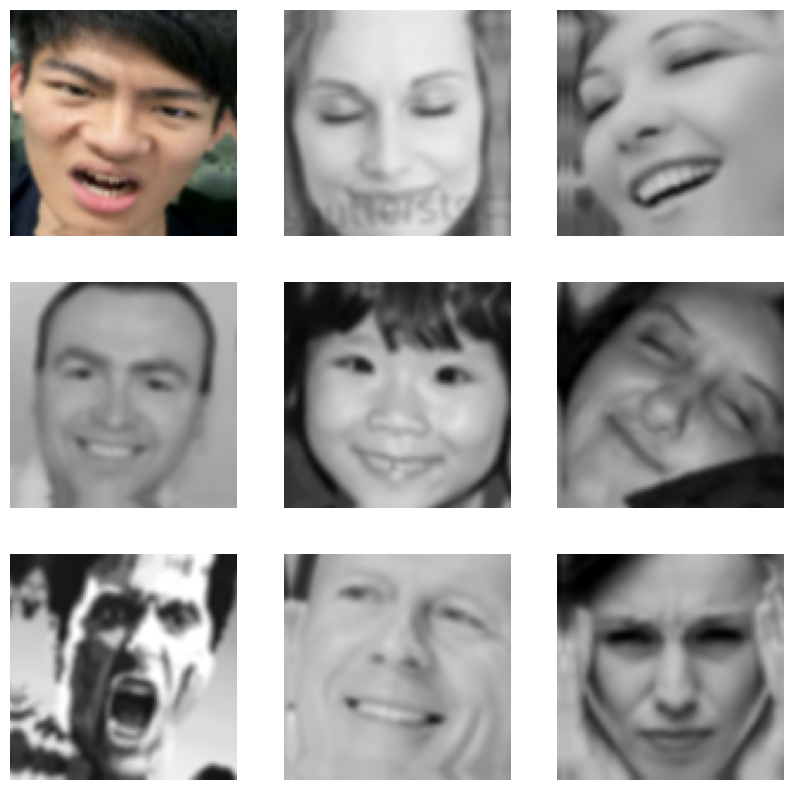

In [30]:
import matplotlib.pyplot as plt

# coger un batch del dataset
for images, labels in train_ds.take(1):
    augmented_images = data_augmentation(images, training=True)

    plt.figure(figsize=(10, 10))

    for i in range(9):  # mostramos 9 imágenes
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

    plt.show()

In [31]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',      
    patience=4,
    restore_best_weights=True
)
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

early_stop_fine = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [32]:
configs = [
    # Modelo base equilibrado (tu actual A mejorado)
    {"name": "A_base", "num_dense_layers": 1, "lr": 1e-4},

    # Modelo más potente (más capacidad)
    {"name": "B_deeper", "num_dense_layers": 2, "lr": 1e-4},

    # Modelo más fino (mejor convergencia)
    {"name": "C_lowLR", "num_dense_layers": 1, "lr": 5e-5},
]

## 2.4 Funciones para calcular accuracy, precision, recall , f1-score y matriz de confusión y luego enviarlas a telegram 

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluar_modelo(history, y_true, y_pred):

    acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]

    print(f"Accuracy final: {acc:.3f}")
    print(f"Validation Accuracy: {val_acc:.3f}")

    # 1. Detectar overfitting
    if acc - val_acc > 0.1:
        print("Posible OVERFITTING")
        
        plt.plot(history.history['accuracy'])
        plt.plot(history.history['val_accuracy'])
        plt.legend(['train', 'val'])
        plt.title('Overfitting Detection')
        plt.show()

    else:
        print("No hay overfitting claro")

    # 2. Detectar underfitting
    if acc < 0.5:
        print("Posible UNDERFITTING")

    # 3. Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Matriz de confusión")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

    # 4. Classification report
    report = classification_report(y_true, y_pred, output_dict=True)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # 5. Detectar clases problemáticas
    for clase, datos in report.items():
        if clase.isdigit():
            recall = datos['recall']
            if recall < 0.6:
                print(f"Clase {clase} con bajo recall ({recall:.2f})")

                # Mostrar gráfico de esa clase
                plt.bar(['precision', 'recall', 'f1'],
                        [datos['precision'], datos['recall'], datos['f1-score']])
                plt.title(f"Clase problemática: {clase}")
                plt.show()

In [34]:
import requests

TOKEN = "8536752415:AAGnygXDRfAQEOO6yDg78Ia3d_XuhzK9MHg"
CHAT_ID = "8788334375"

def send(msg):
    url = f"https://api.telegram.org/bot{TOKEN}/sendMessage"
    requests.post(url, data={"chat_id": CHAT_ID, "text": msg})

In [35]:
def evaluar_y_notificar(history, y_true, y_pred):

    import numpy as np
    from sklearn.metrics import classification_report

    acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]

    mensaje = f"""
RESULTADOS DEL MODELO Escritorio

Accuracy final: {acc:.3f}
Val Accuracy final: {val_acc:.3f}
"""

    # Overfitting
    if acc - val_acc > 0.1:
        mensaje += "\nOverfitting detectado"

    # Convertir etiquetas
    if len(y_true.shape) > 1:
        y_true = np.argmax(y_true, axis=1)

    if len(y_pred.shape) > 1:
        y_pred = np.argmax(y_pred, axis=1)

    report = classification_report(y_true, y_pred)

    mensaje += "\n\nClassification Report:\n"
    mensaje += report

    send(mensaje)

In [36]:
def send_image(path):
    url = f"https://api.telegram.org/bot{TOKEN}/sendPhoto"
    with open(path, "rb") as img:
        requests.post(url, files={"photo": img}, data={"chat_id": CHAT_ID})

In [ ]:
import os


histories = {}
reports = {}
predictions = {}

num_classes = 5

# y_true SE CALCULA UNA SOLA VEZ (fuera del loop)
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

for cfg in configs:
    print(f"\nTraining model {cfg['name']}...")

    model = build_model(
        num_classes=num_classes,
        num_dense_layers=cfg["num_dense_layers"],
        learning_rate=cfg["lr"],
        train_backbone=False
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        callbacks=[early_stop, lr_scheduler]
    )
    # ACTIVAR BACKBONE
    model.layers[1].trainable = True  

    # congelar todo menos últimas capas
    for layer in model.layers[1].layers[:-30]:
        layer.trainable = False

    # recompilar con LR bajo
    model.compile(
        optimizer=tf.keras.optimizers.Adam(3e-5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[early_stop_fine, lr_scheduler]
    )

    # PREDICCIÓN (ANTES DE MÉTRICAS)
    y_pred = model.predict(test_ds)
    y_pred = np.argmax(y_pred, axis=1)

    # guardar historial
    histories[cfg["name"]] = {
        "fase1": history,
        "fase2": history_fine
    }

    predictions[cfg["name"]] = y_pred

    # ahora SÍ puedes calcular el report
    reports[cfg["name"]] = classification_report(
        y_true,
        y_pred,
        output_dict=True
    )

    # Evaluación
    evaluar_modelo(history_fine, y_true, y_pred)
    evaluar_y_notificar(history_fine, y_true, y_pred)

    ruta = "d:/3 CURSO/Segundo cuatri/IA 2/Lab 2/modelsTransfer"
    os.makedirs(ruta, exist_ok=True)

    # Guardar modelo
    model.save(f"d:/3 CURSO/Segundo cuatri/IA 2/Lab 2/modelsTransfer/model_{cfg['name']}.keras")

    # Notificación
    send(f"Modelo {cfg['name']} terminado")


Training model A_base...
Epoch 1/10
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 613s 463ms/step - accuracy: 0.4238 - loss: 1.6325 - precision: 0.4993 - recall: 0.3050 - val_accuracy: 0.5276 - val_loss: 1.2893 - val_precision: 0.6665 - val_recall: 0.3619 - learning_rate: 1.0000e-04
Epoch 2/10
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 528s 409ms/step - accuracy: 0.4859 - loss: 1.4135 - precision: 0.5955 - recall: 0.3371 - val_accuracy: 0.5570 - val_loss: 1.2291 - val_precision: 0.7142 - val_recall: 0.3711 - learning_rate: 1.0000e-04
Epoch 3/10
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 531s 411ms/step - accuracy: 0.5102 - loss: 1.3390 - precision: 0.6369 - recall: 0.3442 - val_accuracy: 0.5696 - val_loss: 1.2018 - val_precision: 0.7196 - val_recall: 0.3991 - learning_rate: 1.0000e-04
Epoch 4/10
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 535s 414ms/step - accuracy: 0.5324 - loss: 1.2824 - precision: 0.6724 - recall: 0.3579 - val_accuracy: 0.5809 - val_loss: 1.1777 - val_precision: 0.7343 - val_recall: 0.3966 - learning_rate: 1.0000e-0

## 2.6 Resultados obtenidos

Accuracy y Validation

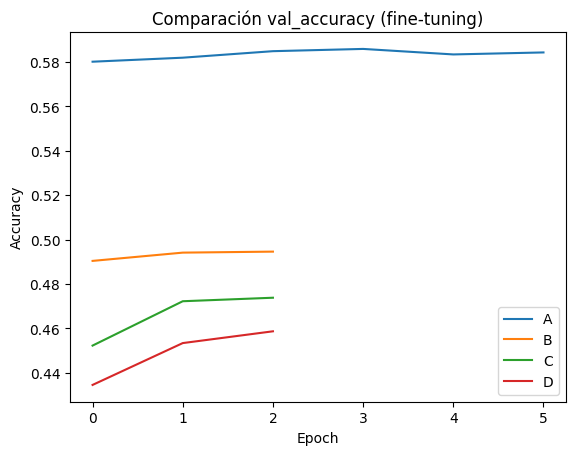

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

for name, h in histories.items():
    plt.plot(h["fase2"].history['val_accuracy'], label=name)

plt.legend()
plt.title('Comparación val_accuracy (fine-tuning)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

Loss y Accuracy

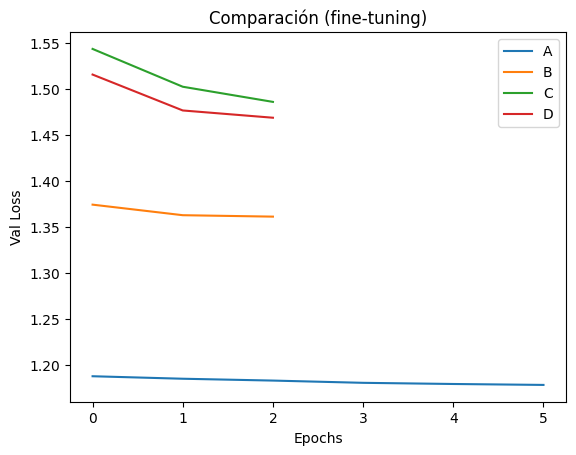

In [ ]:
for name, h in histories.items():
    plt.plot(h["fase2"].history['val_loss'], label=name)

plt.title("Comparación (fine-tuning)")
plt.xlabel("Epochs")
plt.ylabel("Val Loss")
plt.legend()
plt.show()

In [ ]:
for name, y_pred in predictions.items():
    print(f"\nModelo {name}")
    print(classification_report(y_true, y_pred))


Modelo A
              precision    recall  f1-score   support

           0       0.45      0.39      0.42      1523
           1       0.49      0.23      0.31      1461
           2       0.67      0.85      0.75      2767
           3       0.50      0.50      0.50      1884
           4       0.63      0.74      0.68      1235

    accuracy                           0.58      8870
   macro avg       0.55      0.54      0.53      8870
weighted avg       0.56      0.58      0.56      8870


Modelo B
              precision    recall  f1-score   support

           0       0.36      0.30      0.33      1523
           1       0.40      0.19      0.26      1461
           2       0.56      0.83      0.66      2767
           3       0.49      0.34      0.40      1884
           4       0.53      0.62      0.57      1235

    accuracy                           0.50      8870
   macro avg       0.47      0.46      0.45      8870
weighted avg       0.48      0.50      0.47      8870


M

Muestra de matriz de confusión

In [ ]:
for k, v in predictions.items():
    print(k, type(v), len(v))

A <class 'numpy.ndarray'> 8870
B <class 'numpy.ndarray'> 8870
C <class 'numpy.ndarray'> 8870
D <class 'numpy.ndarray'> 8870


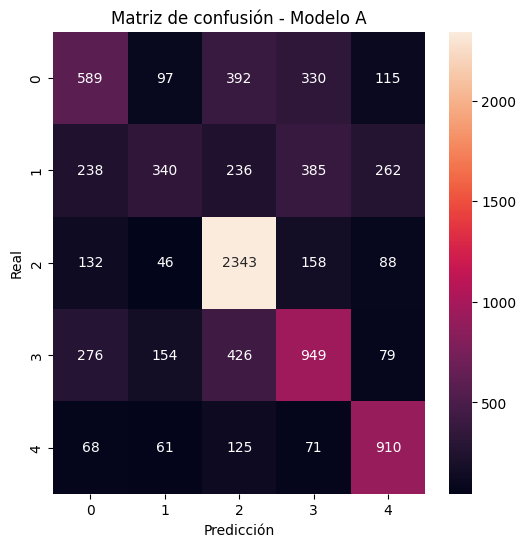

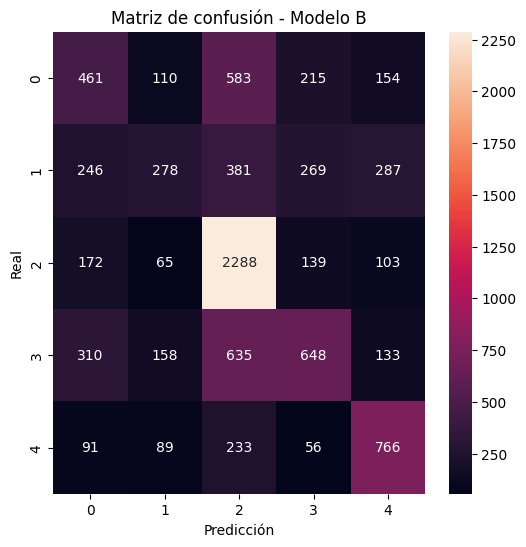

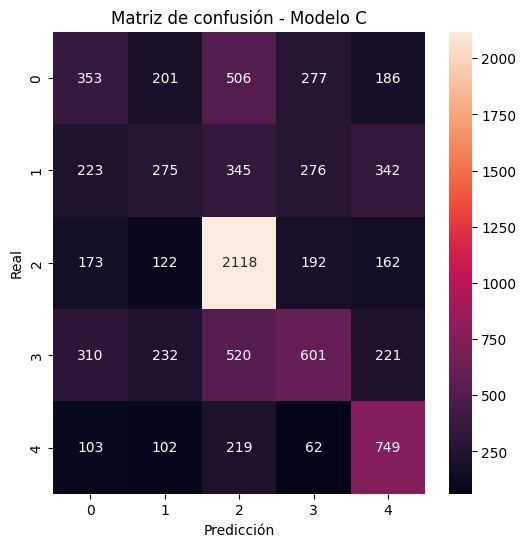

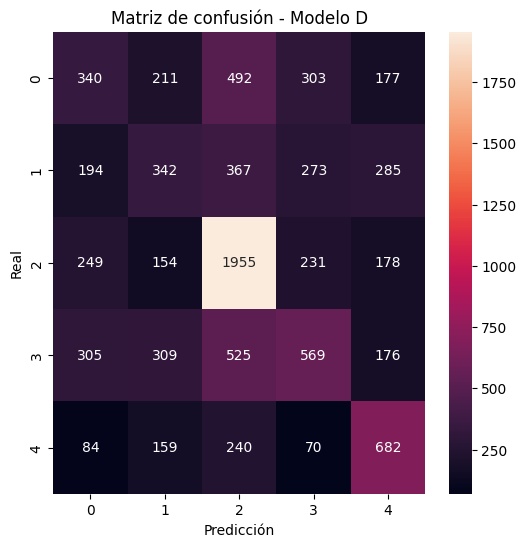

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
for name, y_pred in predictions.items():
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Matriz de confusión - Modelo {name}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

Resultados del modelo pasándolo a telegram

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model_name = "A"  # cambia A, B, C

y_pred = predictions[model_name]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title(f"Matriz de Confusión - Modelo {model_name}")

plt.savefig(f"confusion_matrix_{model_name}.png")
plt.close()

send_image(f"confusion_matrix_{model_name}.png")

# 3. Prueba al modelo con imágenes 

In [ ]:
%pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
print(os.getcwd())

D:\Laboratorio\Lab2-IA2


In [ ]:
import os
print(os.listdir("d:/3 CURSO/Segundo cuatri/IA 2/Lab 2"))

['modelsTransfer']


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

class_names = ["Angry","Fear", "Happy", "Sad", "Surprise"]
imgs = ["New_images/Fear.jpg", "New_images/Happy.jpg", "New_images/Sad.jpg", "New_images/Surprise.jpg"]

def predict_and_plot(model, model_name):
    plt.figure(figsize=(10, 6))

    for i, img_path in enumerate(imgs):

        # cargar imagen
        img = image.load_img(img_path, target_size=(96, 96))
        x = image.img_to_array(img) / 255.0
        x = np.expand_dims(x, axis=0)

        # predicción
        preds = model.predict(x, verbose=0)[0]

        class_idx = np.argmax(preds)
        confidence = preds[class_idx] * 100

        # mostrar imagen
        plt.subplot(2, 2, i + 1)
        plt.imshow(image.load_img(img_path))
        plt.axis("off")

        plt.title(f"{class_names[class_idx]} ({confidence:.2f}%)")

    plt.suptitle(f"Modelo {model_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

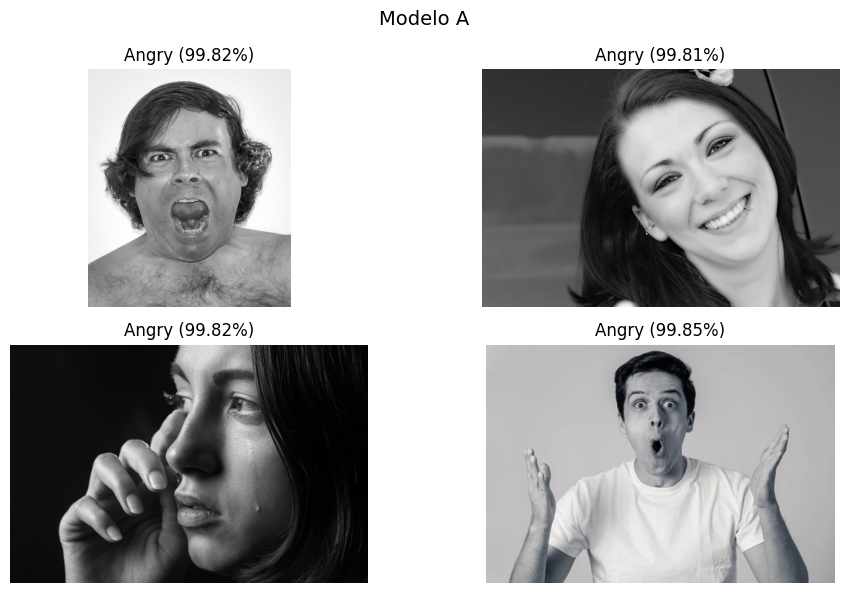

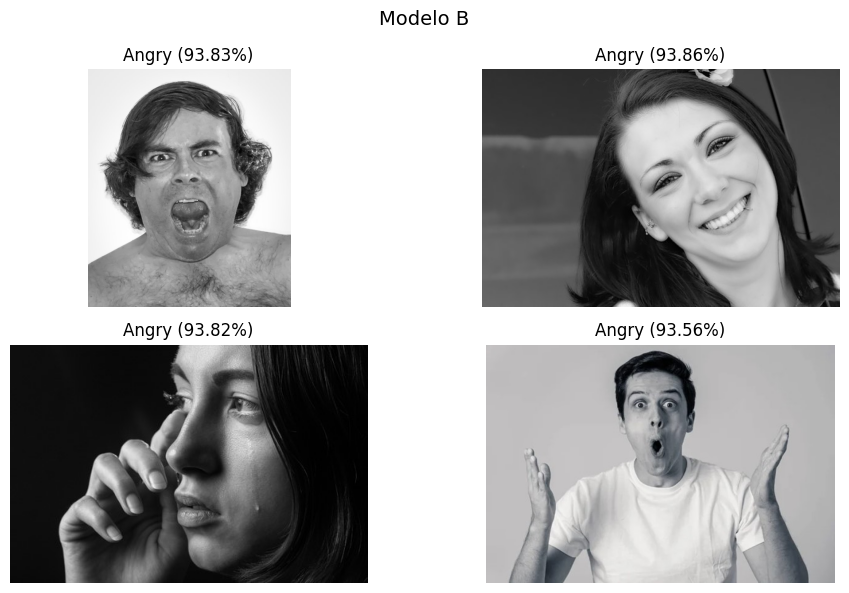

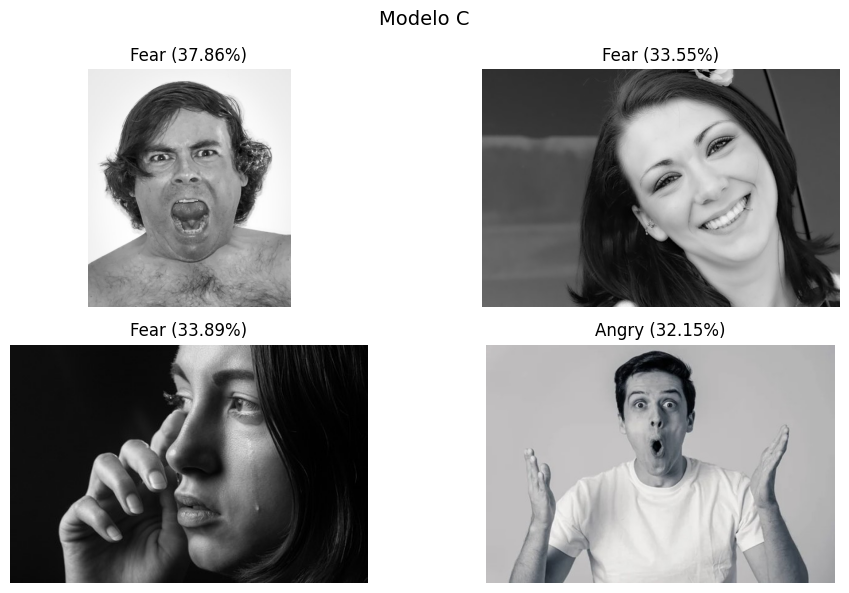

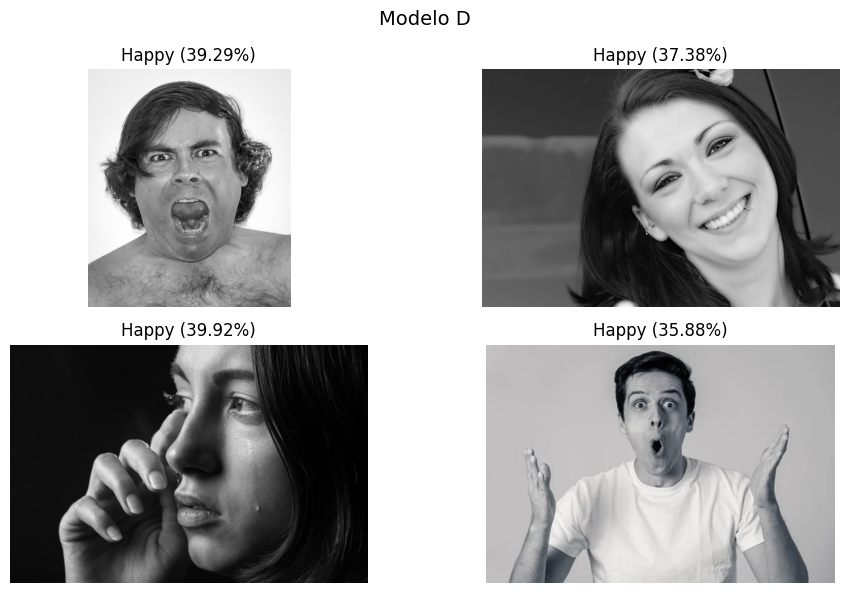

In [ ]:
from tensorflow.keras.models import load_model
my_models={
    "A": load_model("d:/3 CURSO/Segundo cuatri/IA 2/Lab 2/modelsTransfer/model_A.keras"),
    "B": load_model("d:/3 CURSO/Segundo cuatri/IA 2/Lab 2/modelsTransfer/model_B.keras"),
    "C": load_model("d:/3 CURSO/Segundo cuatri/IA 2/Lab 2/modelsTransfer/model_C.keras"),
    "D": load_model("d:/3 CURSO/Segundo cuatri/IA 2/Lab 2/modelsTransfer/model_D.keras"),
}
for name, model in my_models.items():
    predict_and_plot(model, name)